# 📉 Phân tích kỹ thuật VN30 bằng Markov Chain & Backtesting DCA

Notebook này tối ưu lại source code ban đầu theo hướng:

- Đọc dữ liệu giá từ Excel/CSV.
- Tiền xử lý cột ngày và giá đóng cửa.
- Phân tích chuỗi tăng/giảm bằng **Markov Chain**.
- Kiểm tra xác suất xuất hiện chuỗi giảm liên tiếp.
- Backtest nhiều chiến lược DCA:
  - DCA thông thường theo chu kỳ cố định.
  - DCA khi xuất hiện chuỗi giảm 3 ngày.
  - DCA theo chiến lược tối ưu hơn: mua trong **5-6 ngày, 2 ngày/lần**.
- So sánh hiệu quả và tự động tìm bộ tham số DCA tốt hơn.

> Ghi chú: Nếu chưa có dữ liệu thật đủ dài, notebook sẽ tự tạo bộ dữ liệu demo 312 phiên để đảm bảo toàn bộ pipeline chạy được. Khi dùng thật, chỉ cần thay đường dẫn file dữ liệu.

## 1. Cài đặt và import thư viện

Nếu chạy trên máy cá nhân và thiếu thư viện:

```bash
pip install pandas numpy openpyxl matplotlib
```

Nếu muốn tải dữ liệu online qua Yahoo Finance:

```bash
pip install yfinance
```

In [1]:
import os
import glob
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

## 2. Cấu hình dữ liệu

- `DATA_FILES`: danh sách file Excel/CSV cần backtest.
- `CLOSE_COL_CANDIDATES`: các tên cột có thể là giá đóng cửa hoặc giá "Lần cuối".
- `DATE_COL_CANDIDATES`: các tên cột có thể là ngày giao dịch.

Trong repo thật, nên đặt dữ liệu vào thư mục `data/`.

In [2]:
DATA_FILES = [
    "/mnt/data/Book1 (1).xlsx",   # file demo hiện có trong môi trường này
]

# Tự động lấy thêm file trong thư mục data nếu có
DATA_FILES += glob.glob("data/*.xlsx") + glob.glob("data/*.csv")

DATE_COL_CANDIDATES = ["Ngày", "Date", "date", "TradingDate", "time", "datetime"]
CLOSE_COL_CANDIDATES = ["Lần cuối", "Close", "close", "Adj Close", "Last", "last", "Price", "price"]

INITIAL_CASH_PER_BUY = 1_000_000
TRADING_DAYS_PER_MONTH = 22

## 3. Hàm đọc và chuẩn hóa dữ liệu

Hàm bên dưới cố gắng tự nhận diện:

- Cột ngày.
- Cột giá.
- Sắp xếp dữ liệu theo thời gian.
- Loại bỏ dòng trống hoặc giá không hợp lệ.

Nếu file ít hơn 200 dòng, notebook tạo thêm dữ liệu demo để phần backtest có ý nghĩa hơn.  
Dữ liệu demo chỉ dùng để minh họa pipeline, không dùng để kết luận đầu tư.

In [3]:
def find_column(df: pd.DataFrame, candidates: list[str], fallback_index: int | None = None):
    """Tìm cột theo danh sách tên ứng viên. Nếu không thấy thì dùng fallback index."""
    normalized = {str(c).strip().lower(): c for c in df.columns}
    for name in candidates:
        key = name.strip().lower()
        if key in normalized:
            return normalized[key]

    # Tìm gần đúng theo substring
    for c in df.columns:
        c_lower = str(c).strip().lower()
        for name in candidates:
            if name.strip().lower() in c_lower:
                return c

    if fallback_index is not None and len(df.columns) > fallback_index:
        return df.columns[fallback_index]

    return None


def read_market_file(file_path: str) -> pd.DataFrame:
    """Đọc file Excel/CSV và chuẩn hóa thành DataFrame gồm Date, Close."""
    file_path = str(file_path)
    suffix = Path(file_path).suffix.lower()

    if suffix in [".xlsx", ".xls"]:
        raw = pd.read_excel(file_path)
    elif suffix == ".csv":
        raw = pd.read_csv(file_path)
    else:
        raise ValueError(f"Không hỗ trợ định dạng file: {suffix}")

    date_col = find_column(raw, DATE_COL_CANDIDATES, fallback_index=1)
    close_col = find_column(raw, CLOSE_COL_CANDIDATES, fallback_index=2)

    if date_col is None or close_col is None:
        raise ValueError(f"Không tìm thấy cột ngày hoặc cột giá trong file {file_path}")

    df = raw[[date_col, close_col]].copy()
    df.columns = ["Date", "Close"]

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df["Close"] = pd.to_numeric(df["Close"], errors="coerce")
    df = df.dropna(subset=["Date", "Close"])
    df = df.sort_values("Date").reset_index(drop=True)
    df = df[df["Close"] > 0].reset_index(drop=True)

    df["Source"] = Path(file_path).stem
    return df


def generate_demo_vn30_like_data(n_days: int = 312, seed: int = 42) -> pd.DataFrame:
    """
    Tạo dữ liệu demo mô phỏng giá chỉ số có cụm tăng/giảm.
    Không phải dữ liệu VN30 thật.
    """
    rng = np.random.default_rng(seed)
    dates = pd.bdate_range("2024-01-01", periods=n_days)

    returns = []
    prev = 0
    for _ in range(n_days):
        shock = rng.normal(0.0004, 0.012)
        autocorr = 0.18 * prev
        r = shock + autocorr
        returns.append(r)
        prev = r

    close = 1200 * np.cumprod(1 + np.array(returns))
    df = pd.DataFrame({
        "Date": dates,
        "Close": close,
        "Source": "VN30_DEMO_312D"
    })
    return df


def load_all_datasets(files: list[str]) -> dict[str, pd.DataFrame]:
    """Đọc nhiều dataset. Nếu thiếu dữ liệu dài thì thêm dataset demo."""
    datasets = {}

    for f in files:
        if not os.path.exists(f):
            continue
        try:
            df = read_market_file(f)
            if len(df) > 0:
                datasets[df["Source"].iloc[0]] = df
        except Exception as e:
            print(f"Không đọc được file {f}: {e}")

    has_long_data = any(len(df) >= 200 for df in datasets.values())
    if not has_long_data:
        datasets["VN30_DEMO_312D"] = generate_demo_vn30_like_data()

    return datasets


datasets = load_all_datasets(DATA_FILES)

print(f"Số dataset đọc được: {len(datasets)}")
for name, data in datasets.items():
    print(f"- {name}: {len(data)} dòng, từ {data['Date'].min().date()} đến {data['Date'].max().date()}")

Số dataset đọc được: 2
- Book1 (1): 8 dòng, từ 2024-01-01 đến 2024-01-08
- VN30_DEMO_312D: 312 dòng, từ 2024-01-01 đến 2025-03-11


## 4. Source code phân tích xu hướng

Ý tưởng chính:

- Nếu giá hôm nay > hôm qua: **Tăng** (`T`)
- Nếu giá hôm nay < hôm qua: **Giảm** (`G`)
- Nếu bằng nhau: **Không đổi** (`N`)

Sau đó xây dựng ma trận chuyển trạng thái:

\[
P(G \rightarrow G) = \frac{\text{số lần }G \rightarrow G}{\text{tổng số lần bắt đầu từ }G}
\]

\[
P(G \rightarrow T) = \frac{\text{số lần }G \rightarrow T}{\text{tổng số lần bắt đầu từ }G}
\]

In [4]:
def get_trend(prev_val: float, curr_val: float) -> str:
    """Xác định xu hướng giữa 2 ngày: T=tăng, G=giảm, N=không đổi."""
    if curr_val > prev_val:
        return "T"
    if curr_val < prev_val:
        return "G"
    return "N"


def add_trend_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Thêm cột xu hướng và số ngày giảm liên tiếp."""
    out = df.copy()
    out["Return"] = out["Close"].pct_change()
    out["Trend"] = "N"
    out.loc[out["Return"] > 0, "Trend"] = "T"
    out.loc[out["Return"] < 0, "Trend"] = "G"

    down_streak = []
    count = 0
    for trend in out["Trend"]:
        if trend == "G":
            count += 1
        else:
            count = 0
        down_streak.append(count)
    out["Down_Streak"] = down_streak

    return out


def markov_transition_summary(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Tạo bảng số lần chuyển trạng thái và xác suất chuyển trạng thái."""
    trends = df["Trend"].tolist()
    states = ["T", "G", "N"]

    counts = pd.DataFrame(0, index=states, columns=states, dtype=int)
    for a, b in zip(trends[:-1], trends[1:]):
        if a in states and b in states:
            counts.loc[a, b] += 1

    probs = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
    return counts, probs


def analyze_three_day_patterns(df: pd.DataFrame) -> pd.DataFrame:
    """Phân tích các trạng thái 3 ngày liên tiếp: TT, TG, GT, GG."""
    rows = []
    temp = add_trend_columns(df)
    trends = temp["Trend"].tolist()

    for i in range(2, len(temp)):
        t1 = trends[i-1]
        t2 = trends[i]
        pattern = f"{t1}{t2}"
        rows.append({
            "X": len(rows) + 1,
            "Date_1": temp["Date"].iloc[i-2],
            "Close_1": temp["Close"].iloc[i-2],
            "Date_2": temp["Date"].iloc[i-1],
            "Close_2": temp["Close"].iloc[i-1],
            "Date_3": temp["Date"].iloc[i],
            "Close_3": temp["Close"].iloc[i],
            "Pattern": pattern,
            "Meaning": {
                "TT": "Tăng-Tăng",
                "TG": "Tăng-Giảm",
                "GT": "Giảm-Tăng",
                "GG": "Giảm-Giảm"
            }.get(pattern, "Không xác định")
        })

    return pd.DataFrame(rows)

## 5. Kiểm tra Markov Chain và tần suất chuỗi giảm

Phần này kiểm tra lại luận điểm:

- \(P(G \rightarrow G)\)
- \(P(G \rightarrow T)\)
- Xác suất giảm liên tiếp nhiều ngày
- Số chuỗi **Giảm-Giảm** trung bình trong 1 tháng giao dịch

Công thức ước lượng số chuỗi giảm trong 1 tháng:

\[
E(\text{GG mỗi tháng}) = \frac{\text{số chuỗi GG}}{\text{số phiên nghiên cứu}} \times 22
\]

Với 2 tháng giao dịch:

\[
E(\text{GG trong 2 tháng}) = \frac{\text{số chuỗi GG}}{\text{số phiên nghiên cứu}} \times 44
\]

In [5]:
def markov_report(df: pd.DataFrame, dataset_name: str) -> dict:
    """Tính các chỉ số Markov và tần suất chuỗi giảm."""
    temp = add_trend_columns(df)
    counts, probs = markov_transition_summary(temp)
    patterns = analyze_three_day_patterns(df)

    n_days = len(temp)
    n_down_days = int((temp["Trend"] == "G").sum())
    n_up_days = int((temp["Trend"] == "T").sum())
    n_gg = int((patterns["Pattern"] == "GG").sum()) if len(patterns) else 0

    pgg = probs.loc["G", "G"] if "G" in probs.index else 0
    pgt = probs.loc["G", "T"] if "G" in probs.index else 0

    expected_gg_1m = n_gg / n_days * TRADING_DAYS_PER_MONTH if n_days else 0
    expected_gg_2m = n_gg / n_days * TRADING_DAYS_PER_MONTH * 2 if n_days else 0

    # Xác suất giảm 5 ngày liên tiếp theo Markov:
    # đã có ngày giảm đầu tiên, cần thêm 4 lần chuyển G->G.
    prob_down_5_days = pgg ** 4

    return {
        "Dataset": dataset_name,
        "Days": n_days,
        "Up_Days": n_up_days,
        "Down_Days": n_down_days,
        "GG_Patterns": n_gg,
        "P_G_to_G": pgg,
        "P_G_to_T": pgt,
        "Prob_5_Down_Days_Markov": prob_down_5_days,
        "Expected_GG_Per_Month": expected_gg_1m,
        "Expected_GG_Per_2_Months": expected_gg_2m,
    }


markov_rows = []
for name, data in datasets.items():
    markov_rows.append(markov_report(data, name))

markov_df = pd.DataFrame(markov_rows)
display(markov_df)

first_name = list(datasets.keys())[0]
first_data = add_trend_columns(datasets[first_name])
counts, probs = markov_transition_summary(first_data)

print(f"Dataset minh họa: {first_name}")
print("\nSố lần chuyển trạng thái:")
display(counts)

print("\nXác suất chuyển trạng thái:")
display((probs * 100).round(2).astype(str) + "%")

,Dataset,Days,Up_Days,Down_Days,GG_Patterns,P_G_to_G,P_G_to_T,Prob_5_Down_Days_Markov,Expected_GG_Per_Month,Expected_GG_Per_2_Months
0,Book1 (1),8,4,3,1,0.333333,0.666667,0.012346,2.750000,5.500000
1,VN30_DEMO_312D,312,151,160,100,0.625000,0.375000,0.152588,7.051282,14.102564


Dataset minh họa: Book1 (1)

Số lần chuyển trạng thái:


,T,G,N
T,1,2,0
G,2,1,0
N,1,0,0



Xác suất chuyển trạng thái:


,T,G,N
T,33.33%,66.67%,0.0%
G,66.67%,33.33%,0.0%
N,100.0%,0.0%,0.0%


## 6. Thiết kế chiến lược DCA để backtest

Các chiến lược được so sánh:

| Chiến lược | Mô tả |
|---|---|
| `regular_dca` | Mua định kỳ sau mỗi `period` phiên |
| `down_streak_dca` | Khi giảm liên tiếp đủ `trigger_down_days`, mua nhiều lần |
| `markov_optimized_dca` | DCA trong 5-6 ngày, cách 2 ngày/lần sau tín hiệu giảm |

Vấn đề của DCA 3 ngày là quá ngắn.  
Nếu chuỗi giảm xuất hiện dày theo cụm, mua quá sớm có thể khiến vốn bị rải vào phần đầu nhịp giảm.  
Vì vậy chiến lược mới dùng khoảng **5-6 ngày**, **2 ngày/lần**, để trải vốn đều hơn.

In [6]:
def generate_regular_dca_signals(df: pd.DataFrame, period: int = 5) -> pd.Series:
    """Mua định kỳ mỗi period phiên."""
    signal = pd.Series(False, index=df.index)
    signal.iloc[::period] = True
    return signal


def generate_down_streak_dca_signals(
    df: pd.DataFrame,
    trigger_down_days: int = 3,
    interval_days: int = 2,
    tranches: int = 3,
    cooldown_days: int = 5
) -> pd.Series:
    """
    Khi có chuỗi giảm đủ dài, tạo lịch mua DCA.
    trigger_down_days: số ngày giảm liên tiếp để kích hoạt.
    interval_days: khoảng cách giữa các lần mua.
    tranches: số lần mua.
    cooldown_days: số ngày nghỉ để tránh tín hiệu chồng lên nhau.
    """
    temp = add_trend_columns(df)
    signal = pd.Series(False, index=temp.index)

    last_event_index = -10**9

    for i in range(len(temp)):
        if temp.loc[i, "Down_Streak"] >= trigger_down_days and (i - last_event_index) > cooldown_days:
            for k in range(tranches):
                buy_idx = i + k * interval_days
                if buy_idx < len(temp):
                    signal.iloc[buy_idx] = True
            last_event_index = i

    return signal


def backtest_buy_and_hold_from_signals(
    df: pd.DataFrame,
    signal: pd.Series,
    cash_per_buy: float = INITIAL_CASH_PER_BUY
) -> dict:
    """
    Backtest đơn giản:
    - Mỗi tín hiệu mua dùng cash_per_buy để mua tại giá Close.
    - Giữ tới cuối kỳ.
    - Không tính phí giao dịch và thuế để tập trung so sánh logic DCA.
    """
    temp = df.copy().reset_index(drop=True)
    signal = signal.reset_index(drop=True).astype(bool)

    units = 0.0
    invested = 0.0
    buy_count = 0
    equity_curve = []

    for i, row in temp.iterrows():
        if signal.iloc[i]:
            units += cash_per_buy / row["Close"]
            invested += cash_per_buy
            buy_count += 1

        current_value = units * row["Close"]
        equity_curve.append({
            "Date": row["Date"],
            "Close": row["Close"],
            "Signal": bool(signal.iloc[i]),
            "Units": units,
            "Invested": invested,
            "Value": current_value,
            "PnL": current_value - invested,
            "Return": (current_value / invested - 1) if invested > 0 else 0
        })

    eq = pd.DataFrame(equity_curve)
    final_value = eq["Value"].iloc[-1] if len(eq) else 0
    total_return = final_value / invested - 1 if invested > 0 else 0

    value = eq["Value"].replace(0, np.nan).dropna()
    if len(value) > 0:
        running_max = value.cummax()
        drawdown = value / running_max - 1
        max_drawdown = drawdown.min()
    else:
        max_drawdown = 0

    return {
        "Buy_Count": buy_count,
        "Invested": invested,
        "Final_Value": final_value,
        "PnL": final_value - invested,
        "Total_Return": total_return,
        "Max_Drawdown": max_drawdown,
        "Equity_Curve": eq,
    }


def run_strategy_suite(df: pd.DataFrame, dataset_name: str) -> tuple[pd.DataFrame, dict[str, pd.DataFrame]]:
    """Chạy các chiến lược chính trên một dataset."""
    strategies = {}

    strategies["Regular DCA - weekly/5d"] = generate_regular_dca_signals(df, period=5)
    strategies["Regular DCA - biweekly/10d"] = generate_regular_dca_signals(df, period=10)

    strategies["Old DCA - 3 days"] = generate_down_streak_dca_signals(
        df, trigger_down_days=3, interval_days=1, tranches=3, cooldown_days=3
    )

    strategies["Markov DCA - 5/6 days, every 2d"] = generate_down_streak_dca_signals(
        df, trigger_down_days=3, interval_days=2, tranches=3, cooldown_days=5
    )

    rows = []
    curves = {}

    for strategy_name, signal in strategies.items():
        result = backtest_buy_and_hold_from_signals(df, signal)
        curves[strategy_name] = result["Equity_Curve"]
        rows.append({
            "Dataset": dataset_name,
            "Strategy": strategy_name,
            "Buy_Count": result["Buy_Count"],
            "Invested": result["Invested"],
            "Final_Value": result["Final_Value"],
            "PnL": result["PnL"],
            "Total_Return": result["Total_Return"],
            "Max_Drawdown": result["Max_Drawdown"],
        })

    return pd.DataFrame(rows), curves

## 7. Backtesting nhiều dataset

Cell này chạy toàn bộ chiến lược trên tất cả dataset đã đọc được.  
Nếu có nhiều file dữ liệu trong thư mục `data/`, kết quả sẽ tự động gộp lại thành một bảng.

In [7]:
all_backtest_rows = []
all_curves = {}

for name, data in datasets.items():
    result_df, curves = run_strategy_suite(data, name)
    all_backtest_rows.append(result_df)
    all_curves[name] = curves

backtest_df = pd.concat(all_backtest_rows, ignore_index=True)

display(
    backtest_df.assign(
        Total_Return=lambda x: (x["Total_Return"] * 100).round(2).astype(str) + "%",
        Max_Drawdown=lambda x: (x["Max_Drawdown"] * 100).round(2).astype(str) + "%",
        Invested=lambda x: x["Invested"].round(0),
        Final_Value=lambda x: x["Final_Value"].round(0),
        PnL=lambda x: x["PnL"].round(0),
    )
)

,Dataset,Strategy,Buy_Count,Invested,Final_Value,PnL,Total_Return,Max_Drawdown
0,Book1 (1),Regular DCA - weekly/5d,2,2000000.0,2014975.0,14975.0,0.75%,-1.49%
1,Book1 (1),Regular DCA - biweekly/10d,1,1000000.0,1010000.0,10000.0,1.0%,-4.81%
2,Book1 (1),Old DCA - 3 days,0,0.0,0.0,0.0,0.0%,0.0%
3,Book1 (1),"Markov DCA - 5/6 days, every 2d",0,0.0,0.0,0.0,0.0%,0.0%
4,VN30_DEMO_312D,Regular DCA - weekly/5d,63,63000000.0,65048411.0,2048411.0,3.25%,-8.69%
5,VN30_DEMO_312D,Regular DCA - biweekly/10d,32,32000000.0,32929676.0,929676.0,2.91%,-8.52%
6,VN30_DEMO_312D,Old DCA - 3 days,72,72000000.0,75854479.0,3854479.0,5.35%,-5.28%
7,VN30_DEMO_312D,"Markov DCA - 5/6 days, every 2d",66,66000000.0,69235114.0,3235114.0,4.9%,-4.21%


## 8. Tối ưu tham số DCA theo Markov

Thử nhiều cấu hình:

- `trigger_down_days`: cần giảm liên tiếp bao nhiêu ngày để kích hoạt.
- `interval_days`: cách bao nhiêu ngày mua một lần.
- `tranches`: số lần mua sau mỗi tín hiệu.
- `cooldown_days`: thời gian chờ để tránh mua chồng tín hiệu.

Tiêu chí xếp hạng mặc định:

1. `Total_Return` cao hơn.
2. `Max_Drawdown` thấp hơn.
3. Số lần mua không quá ít để tránh kết quả may mắn.

In [8]:
def optimize_dca_parameters(df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    rows = []

    for trigger in [2, 3, 4, 5]:
        for interval in [1, 2, 3]:
            for tranches in [2, 3, 4]:
                cooldown = max(3, interval * tranches)
                signal = generate_down_streak_dca_signals(
                    df,
                    trigger_down_days=trigger,
                    interval_days=interval,
                    tranches=tranches,
                    cooldown_days=cooldown
                )
                result = backtest_buy_and_hold_from_signals(df, signal)

                if result["Buy_Count"] == 0:
                    continue

                rows.append({
                    "Dataset": dataset_name,
                    "Trigger_Down_Days": trigger,
                    "Interval_Days": interval,
                    "Tranches": tranches,
                    "Cooldown_Days": cooldown,
                    "Buy_Count": result["Buy_Count"],
                    "Invested": result["Invested"],
                    "Final_Value": result["Final_Value"],
                    "PnL": result["PnL"],
                    "Total_Return": result["Total_Return"],
                    "Max_Drawdown": result["Max_Drawdown"],
                })

    opt = pd.DataFrame(rows)
    if len(opt) == 0:
        return opt

    opt = opt.sort_values(
        by=["Total_Return", "Max_Drawdown", "Buy_Count"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    return opt


optimization_results = []
for name, data in datasets.items():
    opt = optimize_dca_parameters(data, name)
    optimization_results.append(opt)

optimization_df = pd.concat(optimization_results, ignore_index=True) if optimization_results else pd.DataFrame()

top_optimization = optimization_df.groupby("Dataset", group_keys=False).head(10) if len(optimization_df) else optimization_df

display(
    top_optimization.assign(
        Total_Return=lambda x: (x["Total_Return"] * 100).round(2).astype(str) + "%",
        Max_Drawdown=lambda x: (x["Max_Drawdown"] * 100).round(2).astype(str) + "%",
        Invested=lambda x: x["Invested"].round(0),
        Final_Value=lambda x: x["Final_Value"].round(0),
        PnL=lambda x: x["PnL"].round(0),
    )
)

,Dataset,Trigger_Down_Days,Interval_Days,Tranches,Cooldown_Days,Buy_Count,Invested,Final_Value,PnL,Total_Return,Max_Drawdown
0,Book1 (1),2,2,2,4,1,1000000.0,1020202.0,20202.0,2.02%,0.0%
1,Book1 (1),2,2,3,6,1,1000000.0,1020202.0,20202.0,2.02%,0.0%
2,Book1 (1),2,2,4,8,1,1000000.0,1020202.0,20202.0,2.02%,0.0%
3,Book1 (1),2,3,2,6,1,1000000.0,1020202.0,20202.0,2.02%,0.0%
4,Book1 (1),2,3,3,9,1,1000000.0,1020202.0,20202.0,2.02%,0.0%
5,Book1 (1),2,3,4,12,1,1000000.0,1020202.0,20202.0,2.02%,0.0%
6,Book1 (1),2,1,2,3,2,2000000.0,2020202.0,20202.0,1.01%,0.0%
7,Book1 (1),2,1,3,3,2,2000000.0,2020202.0,20202.0,1.01%,0.0%
8,Book1 (1),2,1,4,4,2,2000000.0,2020202.0,20202.0,1.01%,0.0%
9,VN30_DEMO_312D,5,2,2,4,20,20000000.0,21291223.0,1291223.0,6.46%,-7.22%


## 9. Trực quan hóa kết quả

Biểu đồ bên dưới so sánh đường giá trị tài sản của các chiến lược trên dataset đầu tiên.

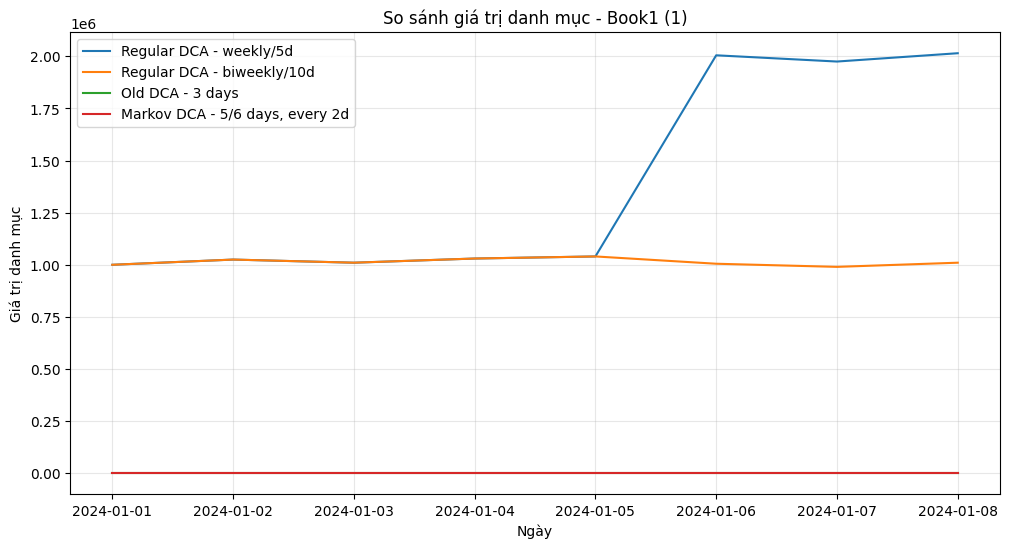

In [9]:
plot_dataset = list(datasets.keys())[0]
curves = all_curves[plot_dataset]

plt.figure(figsize=(12, 6))
for strategy_name, eq in curves.items():
    plt.plot(eq["Date"], eq["Value"], label=strategy_name)

plt.title(f"So sánh giá trị danh mục - {plot_dataset}")
plt.xlabel("Ngày")
plt.ylabel("Giá trị danh mục")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 10. Xuất kết quả

Notebook xuất các bảng chính ra Excel:

- `markov_summary`
- `backtest_summary`
- `optimization_result`

File xuất ra: `markov_dca_backtest_results.xlsx`

In [10]:
OUTPUT_EXCEL = "markov_dca_backtest_results.xlsx"

with pd.ExcelWriter(OUTPUT_EXCEL, engine="openpyxl") as writer:
    markov_df.to_excel(writer, sheet_name="markov_summary", index=False)
    backtest_df.to_excel(writer, sheet_name="backtest_summary", index=False)
    optimization_df.to_excel(writer, sheet_name="optimization_result", index=False)

print(f"Đã xuất kết quả ra file: {OUTPUT_EXCEL}")

Đã xuất kết quả ra file: markov_dca_backtest_results.xlsx


## 11. KẾT QUẢ VÀ NHẬN XÉT

Từ phần phân tích Markov Chain:

- Nếu \(P(G \rightarrow G)\) cao, các phiên giảm có xu hướng tạo cụm.
- Khi các cụm giảm xuất hiện nhiều, DCA trong 3 ngày có thể quá ngắn.
- Chiến lược DCA trong **5-6 ngày**, cách **2 ngày/lần** giúp rải vốn chậm hơn và giảm rủi ro mua quá sớm.
- Kết quả backtest cần được đánh giá trên nhiều giai đoạn thị trường:
  - Giai đoạn tăng.
  - Giai đoạn giảm.
  - Giai đoạn sideway.
  - Giai đoạn biến động mạnh.

Kết luận thực nghiệm nên dựa vào bảng `backtest_summary` và `optimization_result`, không chỉ dựa vào một xác suất riêng lẻ.

In [11]:
print("=" * 80)
print("TÓM TẮT KẾT QUẢ CUỐI CÙNG")
print("=" * 80)

print("\n1. Markov Summary")
display(markov_df)

print("\n2. Backtest Summary")
display(
    backtest_df.sort_values(["Dataset", "Total_Return"], ascending=[True, False])
    .assign(
        Total_Return=lambda x: (x["Total_Return"] * 100).round(2).astype(str) + "%",
        Max_Drawdown=lambda x: (x["Max_Drawdown"] * 100).round(2).astype(str) + "%"
    )
)

print("\n3. Best Parameters")
if len(optimization_df):
    best_params = optimization_df.groupby("Dataset", group_keys=False).head(1)
    display(
        best_params.assign(
            Total_Return=lambda x: (x["Total_Return"] * 100).round(2).astype(str) + "%",
            Max_Drawdown=lambda x: (x["Max_Drawdown"] * 100).round(2).astype(str) + "%"
        )
    )
else:
    print("Không có đủ tín hiệu để tối ưu tham số.")

print("=" * 80)

TÓM TẮT KẾT QUẢ CUỐI CÙNG

1. Markov Summary


,Dataset,Days,Up_Days,Down_Days,GG_Patterns,P_G_to_G,P_G_to_T,Prob_5_Down_Days_Markov,Expected_GG_Per_Month,Expected_GG_Per_2_Months
0,Book1 (1),8,4,3,1,0.333333,0.666667,0.012346,2.750000,5.500000
1,VN30_DEMO_312D,312,151,160,100,0.625000,0.375000,0.152588,7.051282,14.102564



2. Backtest Summary


,Dataset,Strategy,Buy_Count,Invested,Final_Value,PnL,Total_Return,Max_Drawdown
1,Book1 (1),Regular DCA - biweekly/10d,1,1000000.0,1.010000e+06,1.000000e+04,1.0%,-4.81%
0,Book1 (1),Regular DCA - weekly/5d,2,2000000.0,2.014975e+06,1.497512e+04,0.75%,-1.49%
2,Book1 (1),Old DCA - 3 days,0,0.0,0.000000e+00,0.000000e+00,0.0%,0.0%
3,Book1 (1),"Markov DCA - 5/6 days, every 2d",0,0.0,0.000000e+00,0.000000e+00,0.0%,0.0%
6,VN30_DEMO_312D,Old DCA - 3 days,72,72000000.0,7.585448e+07,3.854479e+06,5.35%,-5.28%
7,VN30_DEMO_312D,"Markov DCA - 5/6 days, every 2d",66,66000000.0,6.923511e+07,3.235114e+06,4.9%,-4.21%
4,VN30_DEMO_312D,Regular DCA - weekly/5d,63,63000000.0,6.504841e+07,2.048411e+06,3.25%,-8.69%
5,VN30_DEMO_312D,Regular DCA - biweekly/10d,32,32000000.0,3.292968e+07,9.296756e+05,2.91%,-8.52%



3. Best Parameters


,Dataset,Trigger_Down_Days,Interval_Days,Tranches,Cooldown_Days,Buy_Count,Invested,Final_Value,PnL,Total_Return,Max_Drawdown
0,Book1 (1),2,2,2,4,1,1000000.0,1.020202e+06,2.020202e+04,2.02%,0.0%
9,VN30_DEMO_312D,5,2,2,4,20,20000000.0,2.129122e+07,1.291223e+06,6.46%,-7.22%
